29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Full training data shape: (60000, 28, 28), Full training labels shape: (60000,)
Test data shape: (10000, 28, 28), Test labels shape: (10000,)
Training data shape: (48000, 28, 28), Training labels shape: (48000,)
Validation data shape: (12000, 28, 28), Validation labels shape: (12000,)


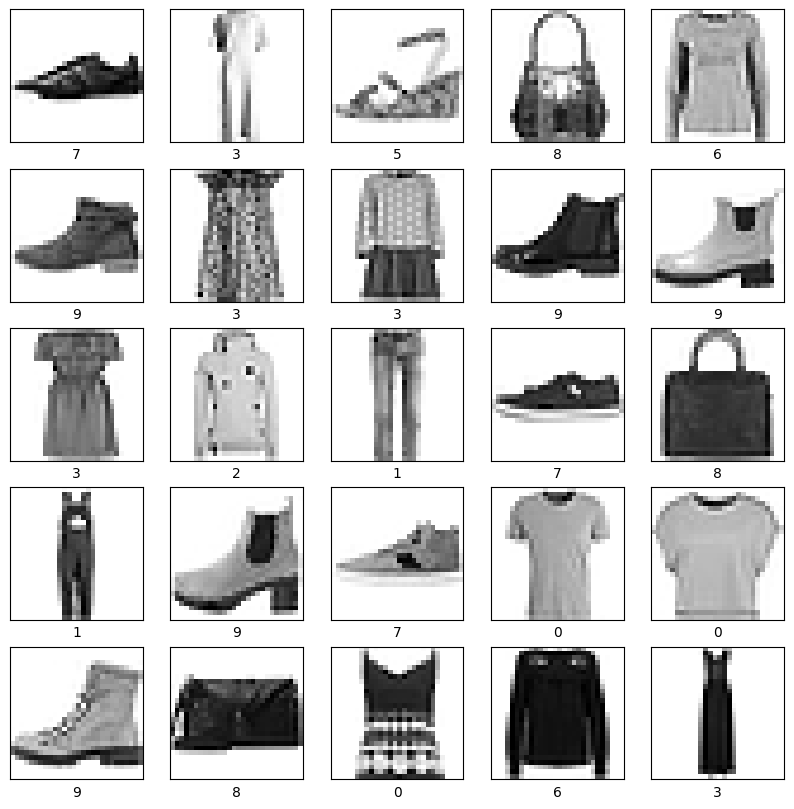

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# 1. Load the Fashion MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Preprocess the data:
# Normalize pixel values to be between 0 and 1
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Full training data shape: {X_train_full.shape}, Full training labels shape: {y_train_full.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, Validation labels shape: {y_val.shape}")

# Display a few images from the dataset
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i]) # Display class label
plt.show()

In [ ]:
def build_and_train_model(initializer, initializer_name, learning_rate=0.001, epochs=20, weight_decay=0.0):
    print(f"\n--- Training with {initializer_name} Initialization, LR={learning_rate}, Weight Decay={weight_decay} ---")

    # Build a simple MLP model for Fashion MNIST
    # Flatten the 28x28 images into a 784-dimensional vector
    model = Sequential([
        Flatten(input_shape=(28, 28)), # Input layer to flatten images
        Dense(128, activation='relu', kernel_initializer=initializer, bias_initializer='zeros', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        Dense(64, activation='relu', kernel_initializer=initializer, bias_initializer='zeros', kernel_regularizer=tf.keras.regularizers.l2(weight_decay)),
        Dense(10, activation='softmax', kernel_initializer=initializer, bias_initializer='zeros') # 10 classes for Fashion MNIST
    ])

    # Compile the model with the specified learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=64, validation_data=(X_val, y_val), verbose=0)

    # Plot training and validation loss
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss vs. Epochs ({initializer_name} Initialization, LR={learning_rate}, WD={weight_decay})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
    print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    return history

### Experiment 4: He Normal Initialization with Different Learning Rates


--- Training with He Normal (LR=0.0001) Initialization and Learning Rate: 0.0001 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


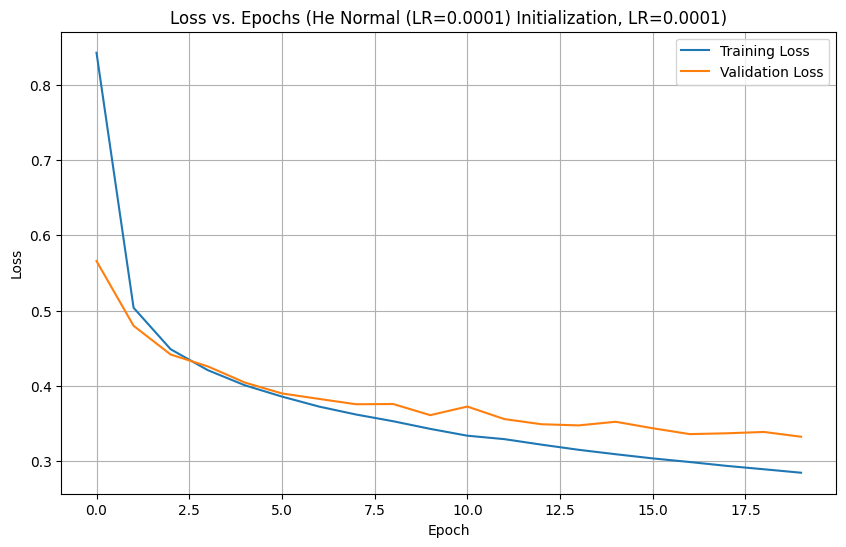

Final Training Loss: 0.2842
Final Validation Loss: 0.3320
Final Training Accuracy: 0.8989
Final Validation Accuracy: 0.8807


In [ ]:
# Experiment with a small learning rate
history_he_small_lr = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (LR=0.0001)',
    learning_rate=0.0001,
    epochs=20
)


--- Training with He Normal (LR=0.001) Initialization and Learning Rate: 0.001 ---


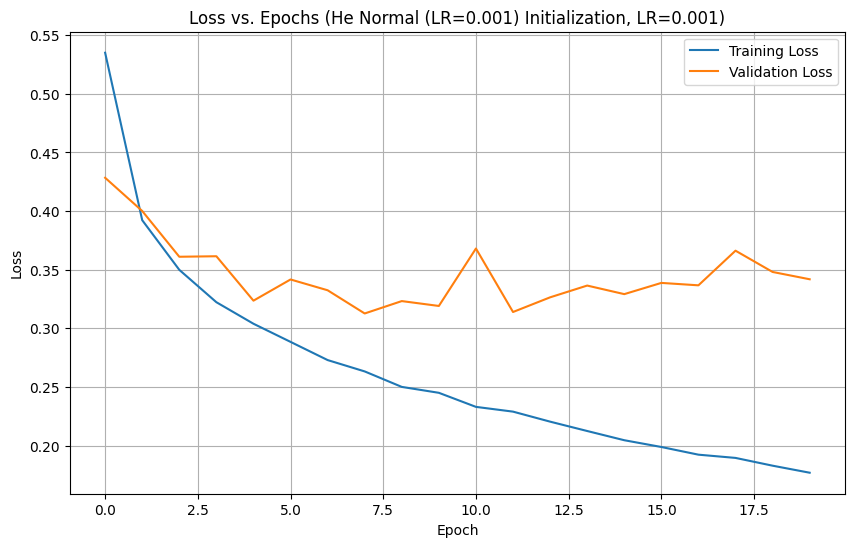

Final Training Loss: 0.1769
Final Validation Loss: 0.3418
Final Training Accuracy: 0.9333
Final Validation Accuracy: 0.8861


In [ ]:
# Experiment with a default learning rate
history_he_default_lr = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (LR=0.001)',
    learning_rate=0.001,
    epochs=20
)


--- Training with He Normal (LR=0.01) Initialization and Learning Rate: 0.01 ---


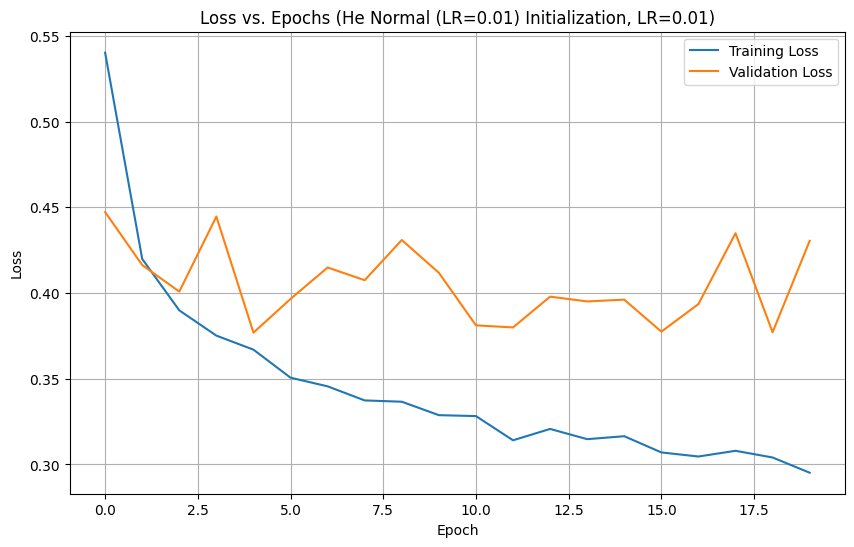

Final Training Loss: 0.2951
Final Validation Loss: 0.4304
Final Training Accuracy: 0.8935
Final Validation Accuracy: 0.8692


In [ ]:
# Experiment with a larger learning rate
history_he_large_lr = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (LR=0.01)',
    learning_rate=0.01,
    epochs=20
)

### Experiment 5: Increased Epochs with Optimal Learning Rate


--- Training with He Normal (LR=0.001, 50 Epochs) Initialization and Learning Rate: 0.001 ---


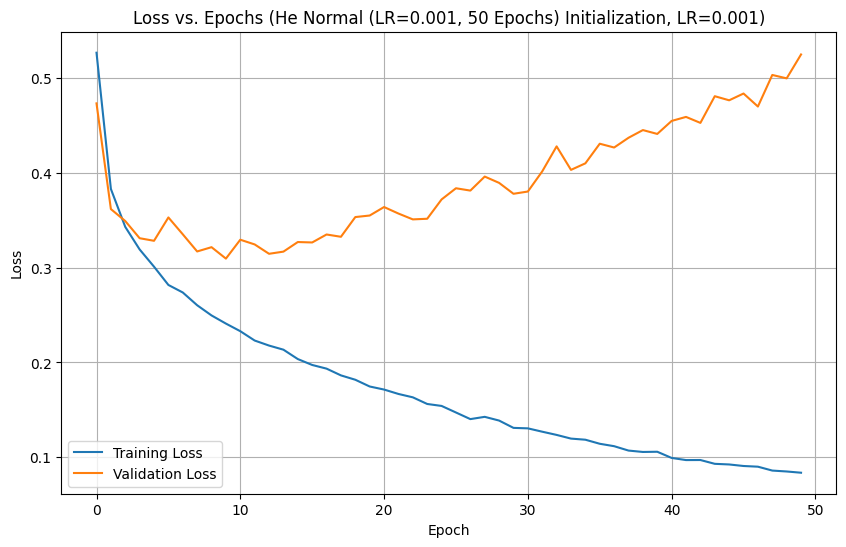

Final Training Loss: 0.0836
Final Validation Loss: 0.5251
Final Training Accuracy: 0.9690
Final Validation Accuracy: 0.8856


In [ ]:
# Choose one of the better performing learning rates (e.g., 0.001) and increase epochs
history_he_increased_epochs = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (LR=0.001, 50 Epochs)',
    learning_rate=0.001,
    epochs=50 # Increased epochs
)

### Experiment 6: He Normal Initialization with Different Weight Decay (Lambda) Values


--- Training with He Normal (WD=0.0001) Initialization, LR=0.001, Weight Decay=0.0001 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


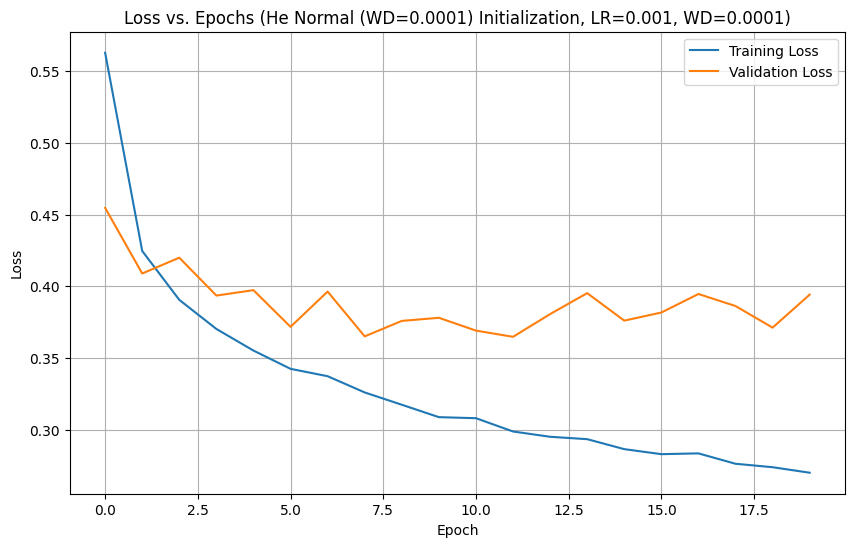

Final Training Loss: 0.2701
Final Validation Loss: 0.3943
Final Training Accuracy: 0.9190
Final Validation Accuracy: 0.8832


In [ ]:
# Experiment with a low weight decay (lambda)
history_wd_low = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (WD=0.0001)',
    learning_rate=0.001,
    epochs=20,
    weight_decay=0.0001
)


--- Training with He Normal (WD=0.001) Initialization, LR=0.001, Weight Decay=0.001 ---


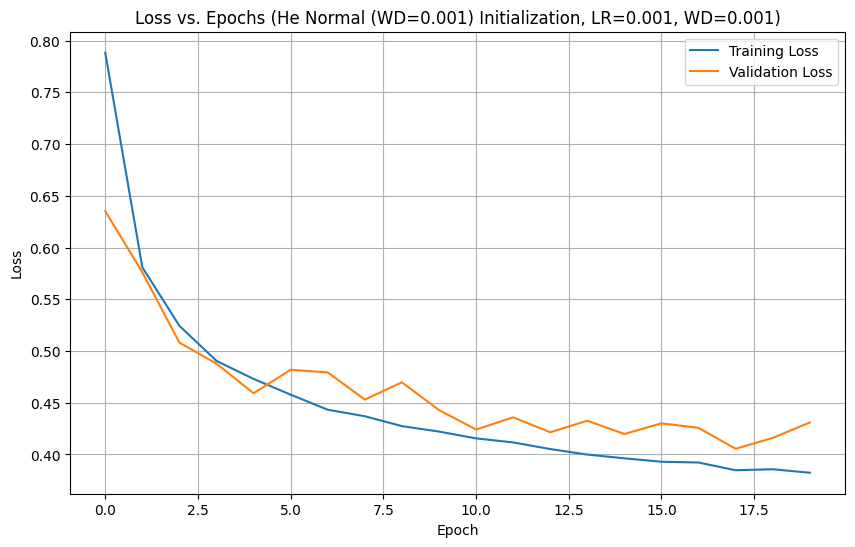

Final Training Loss: 0.3824
Final Validation Loss: 0.4309
Final Training Accuracy: 0.8873
Final Validation Accuracy: 0.8731


In [ ]:
# Experiment with a moderate weight decay (lambda)
history_wd_medium = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (WD=0.001)',
    learning_rate=0.001,
    epochs=20,
    weight_decay=0.001
)


--- Training with He Normal (WD=0.01) Initialization, LR=0.001, Weight Decay=0.01 ---


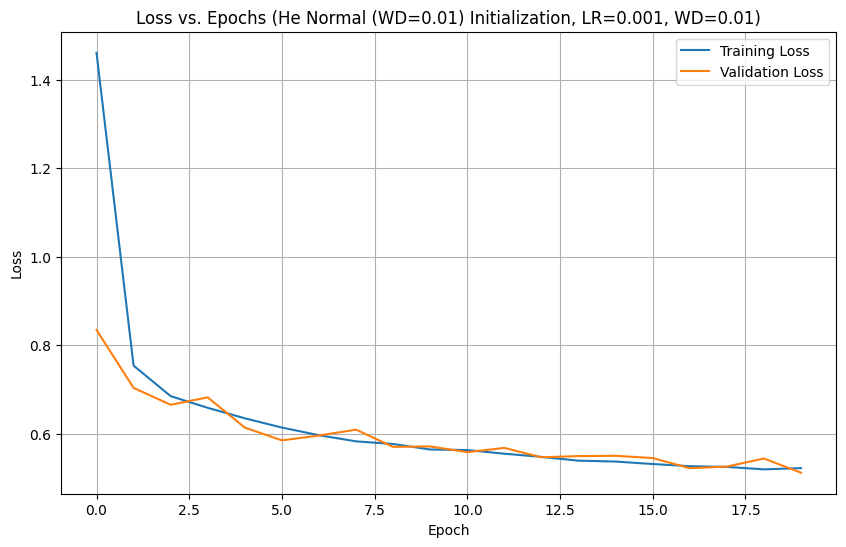

Final Training Loss: 0.5219
Final Validation Loss: 0.5115
Final Training Accuracy: 0.8482
Final Validation Accuracy: 0.8533


In [ ]:
# Experiment with a high weight decay (lambda)
history_wd_high = build_and_train_model(
    initializer=tf.keras.initializers.HeNormal(),
    initializer_name='He Normal (WD=0.01)',
    learning_rate=0.001,
    epochs=20,
    weight_decay=0.01
)

### Experiment 1: Zero Initialization


--- Training with Zeros Initialization ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


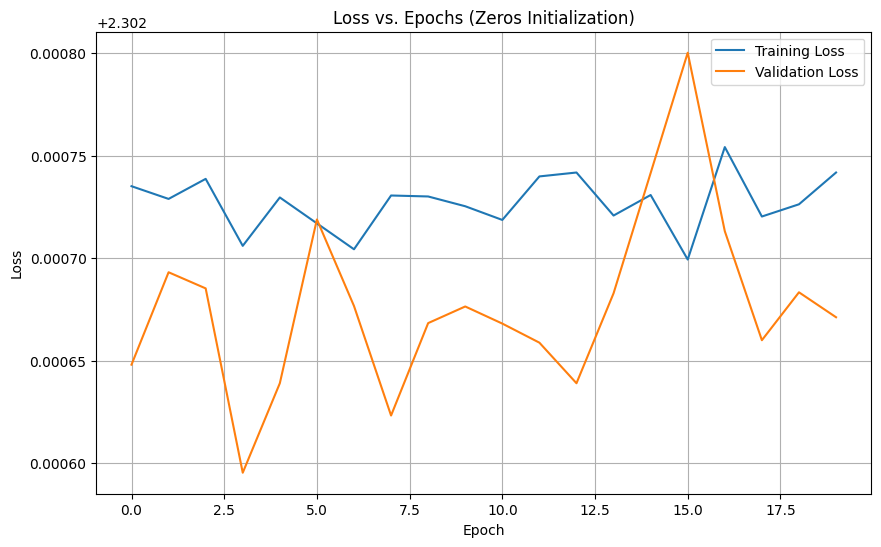

Final Training Loss: 2.3027
Final Validation Loss: 2.3027
Final Training Accuracy: 0.0986
Final Validation Accuracy: 0.0966


In [ ]:
history_zeros = build_and_train_model(
    initializer=tf.keras.initializers.Zeros(),
    initializer_name='Zeros'
)

### Experiment 2: Constant Initialization (e.g., 0.1)


--- Training with Constant (0.1) Initialization ---


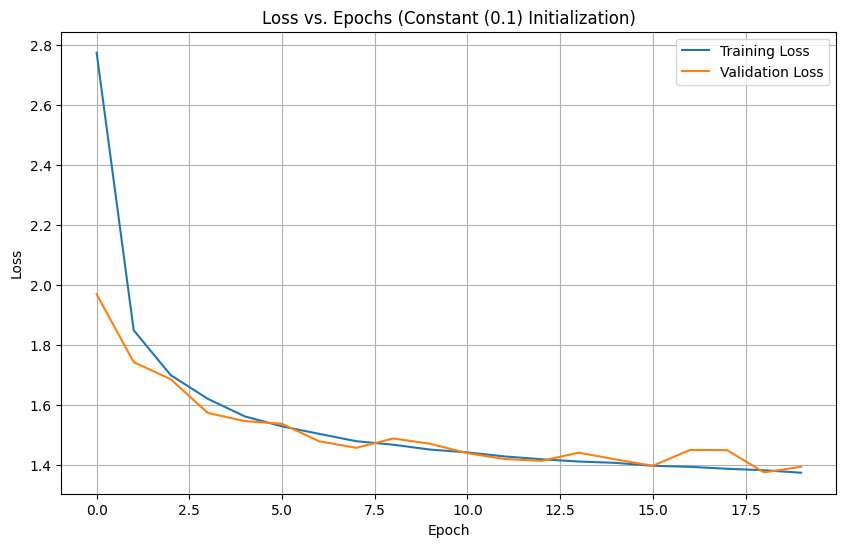

Final Training Loss: 1.3728
Final Validation Loss: 1.3926
Final Training Accuracy: 0.3837
Final Validation Accuracy: 0.3820


In [ ]:
history_constant = build_and_train_model(
    initializer=tf.keras.initializers.Constant(value=0.1),
    initializer_name='Constant (0.1)'
)

### Experiment 3: Small Variance Normal Distribution (Variance 0.1)


--- Training with Small Normal Initialization ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


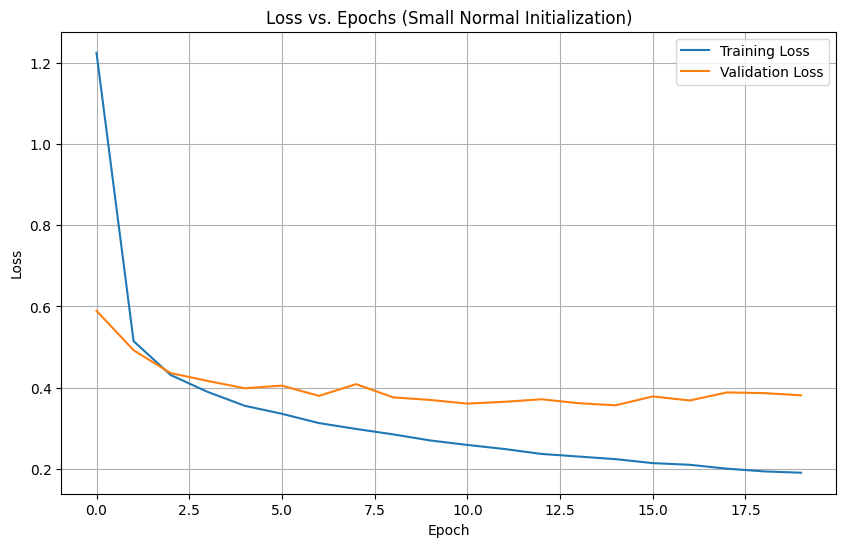

Final Training Loss: 0.1903
Final Validation Loss: 0.3810
Final Training Accuracy: 0.9296
Final Validation Accuracy: 0.8800


In [ ]:
history_large_normal = build_and_train_model(
    initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=np.sqrt(0.1)),
    initializer_name='Small Normal'
)

### Experiment 4: Large Variance Normal Distribution (Variance 1000)


--- Training with Large Normal Initialization ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


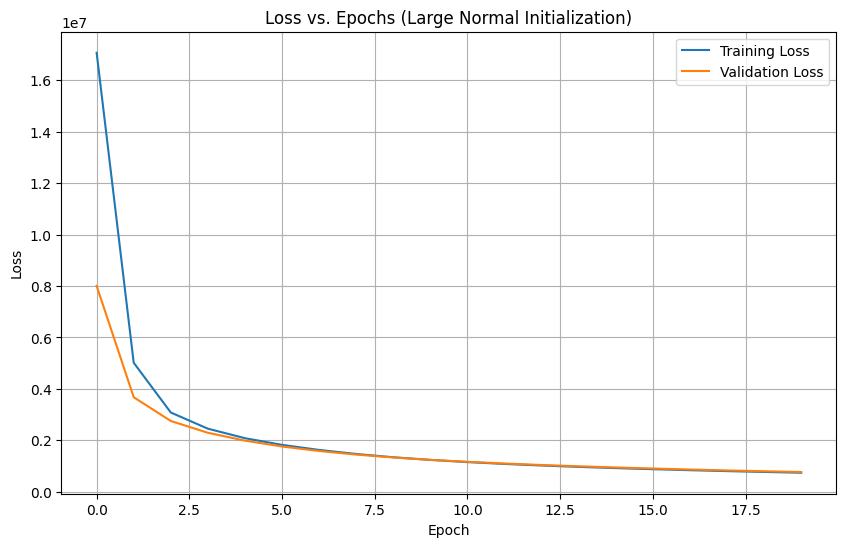

Final Training Loss: 735323.5000
Final Validation Loss: 763062.4375
Final Training Accuracy: 0.7201
Final Validation Accuracy: 0.7111


In [ ]:
history_large_normal = build_and_train_model(
    initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=np.sqrt(1000.0)),
    initializer_name='Large Normal'
)